# Exact Pure-Dephasing Spin-Boson Model

This notebook benchmarks the non-RWA pure-dephasing spin-boson model against OQuPy/TEMPO. The emphasis is on checking the bath correlation function, spectral density convention, TEMPO convergence, and the exact analytical coherence dynamics.

**Notebook map**

1. Imports and helper solver
2. Model definition
3. Bath correlation and spectral density checks
4. TEMPO convergence checks
5. Final TEMPO run
6. Analytical solution and comparison


In [1]:
import warnings
warnings.filterwarnings("ignore", message="Reliance on distutils from stdlib is deprecated.*")
import oqupy as hp
import numpy as np
import qutip as qt
import scipy.integrate as intg
import matplotlib.pyplot as plt
import pandas as pd

## 1. Imports

Load the numerical, plotting, and open-quantum-system libraries used in the benchmark.

## GENERIC OQUPY TEMPO FUNCTION

Generic OQuPy TEMPO solver for the system-bath Hamiltonian:

$$H = H_s + A \otimes B + H_B$$

### Parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| `Hs` | `ndarray` | System Hamiltonian matrix |
| `A` | `ndarray` | System coupling operator |
| `J(w)` | `oqupy correlations object` | Bath correlation/spectral density object. Example: `oqupy.PowerLawSD(...)` |
| `rho0` | `ndarray` | Initial density matrix |
| `dt` | `float` | TEMPO timestep |
| `tcut` | `float` | Memory cutoff time |
| `epsrel` | `float` | Relative precision |
| `t_end` | `float` | Final simulation time |
| `start_time` | `float` | Initial time, fixed 0.0 |

### Returns

| Type | Description |
|------|-------------|
| `dict` | Dictionary containing: |
| | - `dynamics` : The computed dynamics object |
| | - `process_tensor` : The computed process tensor |
| | - `times` : Array of time points |
| | - `states` : Array of system states at each time point |

In [2]:
def run_oqupy_dynamics(Hs, A, correlations, rho0, dt, tcut, epsrel, t_end,):
    system = hp.System(Hs)    # SYSTEM
    bath = hp.Bath(A, correlations)    # BATH
    tempo_parameters = hp.TempoParameters(dt=dt, tcut=tcut, epsrel=epsrel)    # TEMPO PARAMETERS
    pt = hp.pt_tempo_compute(bath=bath, start_time=0.0, end_time=t_end, parameters=tempo_parameters)    # PROCESS TENSOR
    dynamics = hp.compute_dynamics(system=system, process_tensor=pt, initial_state=rho0, start_time=0.0)    # DYNAMICS
    states = dynamics.states    # EXTRACT STATES
    times = dynamics.times
    return {"dynamics": dynamics, "process_tensor": pt, "times": times, "states": states,}

# Exact Pure-Dephasing Spin-Boson Model: Non-RWA Benchmark

## 1. Hamiltonian

Consider the spin-boson Hamiltonian

$$
H=
\frac{\omega_0}{2}\sigma_z
+
\sum_k \omega_k b_k^\dagger b_k
+
\sigma_z\sum_k g_k(b_k+b_k^\dagger),
\qquad g_k\in\mathbb R.
$$

Define

$$
B=\sum_k g_k(b_k+b_k^\dagger).
$$

Then

$$
H_{\rm int}=\sigma_z B.
$$

Because

$$
[\sigma_z,H]=0,
$$

the populations are exactly constant. Only the coherences decay.

---

## 2. Interaction-picture evolution

Use

$$
H_0=
\frac{\omega_0}{2}\sigma_z
+
\sum_k\omega_k b_k^\dagger b_k.
$$

Then

$$
H_{\rm int}^I(t)
=
\sigma_z B(t),
$$

where

$$
B(t)
=
\sum_k g_k
\left(
b_k e^{-i\omega_k t}
+
b_k^\dagger e^{i\omega_k t}
\right).
$$

The bath commutator is a c-number:

$$
[B(t_1),B(t_2)]
=
2i\sum_k g_k^2\sin\omega_k(t_1-t_2).
$$

Therefore the Magnus expansion truncates exactly. The evolution operator is

$$
U_I(t)
=
\exp\left[
-i\sigma_z\int_0^t B(\tau)d\tau
\right]
\times
e^{i\phi(t)},
$$

where $e^{i\phi(t)}$ is a global phase. It cancels from the reduced density matrix.

Define

$$
\Phi(t)=\int_0^t B(\tau)d\tau.
$$

Then the relevant interaction-picture propagator is

$$
U_I(t)=e^{-i\sigma_z\Phi(t)}.
$$

Since $\sigma_z|e\rangle=+|e\rangle$ and $\sigma_z|g\rangle=-|g\rangle$,

$$
U_I(t)
=
|e\rangle\langle e|e^{-i\Phi(t)}
+
|g\rangle\langle g|e^{+i\Phi(t)}.
$$

---

## 3. Exact coherence

For an initially factorized state

$$
\rho(0)=\rho_S(0)\otimes\rho_B,
$$

with $\rho_B$ thermal, the interaction-picture coherence is

$$
\rho_{eg}^I(t)
=
\rho_{eg}(0)
\left\langle e^{-2i\Phi(t)}\right\rangle_B.
$$

Returning to the Schrödinger picture gives

$$
\rho_{eg}(t)
=
\rho_{eg}(0)
e^{-i\omega_0 t}
\left\langle e^{-2i\Phi(t)}\right\rangle_B.
$$

Thus the entire nontrivial part is the Gaussian average

$$
\left\langle e^{-2i\Phi(t)}\right\rangle_B.
$$

---

## 4. Gaussian evaluation

The operator $\Phi(t)$ is linear in bosonic creation and annihilation operators.  
For a thermal Gaussian bath,

$$
\left\langle e^{-2i\Phi(t)}\right\rangle_B
=
\exp\left[
-\frac12\left\langle (2\Phi(t))^2\right\rangle_B
\right].
$$

Therefore

$$
\left\langle e^{-2i\Phi(t)}\right\rangle_B
=
\exp\left[-2\langle \Phi^2(t)\rangle_B\right].
$$

The bath correlation function is

$$
C(t_1-t_2)
=
\langle B(t_1)B(t_2)\rangle_B.
$$

With the convention

$$
J(\omega)=\sum_k g_k^2\delta(\omega-\omega_k),
$$

one has

$$
C(t)
=
\int_0^\infty d\omega\,
J(\omega)
\left[
\coth\left(\frac{\beta\omega}{2}\right)\cos\omega t
-
i\sin\omega t
\right].
$$

Now

$$
\langle \Phi^2(t)\rangle_B
=
\int_0^t d\tau_1
\int_0^t d\tau_2\,
C(\tau_1-\tau_2).
$$

The imaginary part vanishes because

$$
\sin\omega(\tau_1-\tau_2)
$$

is antisymmetric under $\tau_1\leftrightarrow\tau_2$, while the integration domain is symmetric.

Hence

$$
\langle \Phi^2(t)\rangle_B
=
2\int_0^\infty d\omega\,
\frac{J(\omega)}{\omega^2}
(1-\cos\omega t)
\coth\left(\frac{\beta\omega}{2}\right).
$$

Therefore

$$
\left\langle e^{-2i\Phi(t)}\right\rangle_B
=
\exp[-\gamma(t)],
$$

with

$$
\boxed{
\gamma(t)
=
4\int_0^\infty d\omega\,
\frac{J(\omega)}{\omega^2}
(1-\cos\omega t)
\coth\left(\frac{\beta\omega}{2}\right)
}.
$$

This factor $4$ is essential. It comes from the eigenvalue difference of the coupling operator $\sigma_z$:

$$
\Delta s = (+1)-(-1)=2,
\qquad
(\Delta s)^2=4.
$$

If instead the coupling operator were $\sigma_z/2$, this factor would be different.

---

## 5. No bath-induced phase

The decoherence exponent is purely real.

There is no bath-induced Lamb-shift phase in this pure-dephasing model because:

1. $\Phi(t)$ is Hermitian.
2. The square-domain integral kills the imaginary part of $C(t)$.
3. The Magnus commutator term is proportional to $\sigma_z^2=\mathbb I$, so it gives only a global phase.
4. The two conditional bath Hamiltonians $H_B+B$ and $H_B-B$ have the same displacement energy shift, so their difference produces no extra system frequency shift.

Thus

$$
\rho_{eg}(t)
=
\rho_{eg}(0)
e^{-i\omega_0t}
e^{-\gamma(t)}.
$$

The only phase is the bare system phase $e^{-i\omega_0t}$.

---

## 6. Ohmic exponential spectral density

Choose

$$
J(\omega)=2\alpha\omega e^{-\omega/\omega_c},
\qquad \alpha>0.
$$

At zero temperature,

$$
\coth\left(\frac{\beta\omega}{2}\right)\to 1.
$$

Then

$$
\gamma(t)
=
4\int_0^\infty d\omega\,
\frac{2\alpha\omega e^{-\omega/\omega_c}}{\omega^2}
(1-\cos\omega t).
$$

Therefore

$$
\gamma(t)
=
8\alpha
\int_0^\infty \frac{d\omega}{\omega}
e^{-\omega/\omega_c}
(1-\cos\omega t).
$$

Using

$$
\int_0^\infty \frac{dx}{x}e^{-x}(1-\cos bx)
=
\frac12\ln(1+b^2),
$$

with

$$
x=\frac{\omega}{\omega_c},
\qquad
b=\omega_c t,
$$

we obtain

$$
\gamma(t)
=
8\alpha
\cdot
\frac12
\ln(1+\omega_c^2t^2).
$$

Hence

$$
\boxed{
\gamma(t)
=
4\alpha\ln(1+\omega_c^2t^2)
}.
$$

Therefore the exact coherence is

$$
\boxed{
\rho_{eg}(t)
=
\rho_{eg}(0)
e^{-i\omega_0t}
(1+\omega_c^2t^2)^{-4\alpha}
}.
$$

---

## 7. Correlation-function check

At zero temperature,

$$
C(t)
=
\int_0^\infty d\omega\,
2\alpha\omega e^{-\omega/\omega_c}
e^{-i\omega t}.
$$

Since

$$
\int_0^\infty d\omega\,
\omega e^{-a\omega}
=
\frac{1}{a^2},
$$

with

$$
a=\omega_c^{-1}+it,
$$

we get

$$
\boxed{
C(t)
=
\frac{2\alpha}{(\omega_c^{-1}+it)^2}
}.
$$

The square-domain integral gives

$$
\int_0^t d\tau_1
\int_0^t d\tau_2\,
C(\tau_1-\tau_2)
=
2\int_0^\infty d\omega\,
\frac{J(\omega)}{\omega^2}
(1-\cos\omega t).
$$

But the coherence exponent is not this integral directly.  
Because the coherence connects the two $\sigma_z$ branches $+1$ and $-1$, one must include the extra factor

$$
\frac12(\Delta s)^2
=
\frac12(2)^2
=
2.
$$

Thus

$$
\gamma(t)
=
2
\int_0^t d\tau_1
\int_0^t d\tau_2\,
C(\tau_1-\tau_2).
$$

Equivalently,

$$
\gamma(t)
=
4\int_0^\infty d\omega\,
\frac{J(\omega)}{\omega^2}
(1-\cos\omega t).
$$

---

## 8. Numerical matching conditions

The numerical simulation should match the analytical result if and only if the following conventions are consistent:

1. Given coupling operator $A$, $\Delta_A=\lambda_1(A)-\lambda_2(A)$, where $\lambda$ are the eigenvalues of A. For $A = \sigma_z$, $(\Delta_A)^2=4$.
2. The spectral density convention is
   $$
   J(\omega)=\sum_k g_k^2\delta(\omega-\omega_k).
   $$
3. The Ohmic spectral density is
   $$
   J(\omega)=2\alpha\omega e^{-\omega/\omega_c}.
   $$
4. The exact comparison function is
   $$
   \rho_{eg}^{\rm exact}(t)
   =
   \rho_{eg}(0)e^{-i\omega_0t}
   (1+\omega_c^2t^2)^{-(\Delta_A)^2 \alpha}.
   $$
5. After removing the bare phase $e^{-i\omega_0t}$, the remaining coherence should be real and positive.
6. Populations must remain constant for all times.
7. On a log-log plot at large $t$,
   $$
   |\rho_{eg}(t)|\sim t^{-8\alpha}.
   $$

The match occurs because the model is exactly Gaussian and exactly diagonal in $\sigma_z$.  
There is no Born approximation, no Markov approximation, no RWA, and no perturbative truncation.  
TEMPO/OQuPy should reproduce this result when the bath correlation, spectral-density convention, coupling-operator normalization, and time-memory convergence are all consistent.

## 2. Physical parameters and operators

Define the spin-boson model parameters, system Hamiltonian, coupling operator, and initial density matrix.

In [3]:
# =====================================================
# 1. Define physical parameters
# =====================================================
omega0   = 1e-5        # qubit frequency
alpha    = 0.02        # dimensionless coupling strength
omega_c  = 10.0       # cutoff frequency for Ohmic bath
T        = 0.0        # zero temperature

# =====================================================
# 2. System Hamiltonian and coupling operator
# =====================================================
# Use standard Pauli matrices (as numpy arrays)
sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
sigma_y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)

H_sys = 0.5 * omega0 * sigma_z   # system Hamiltonian
A = 0.5 * sigma_z                      # coupling operator σ_z
Delta = np.linalg.eigvalsh(A)[-1] - np.linalg.eigvalsh(A)[0] # energy gap of the system Hamiltonian

# =====================================================
# 3. Bath spectral density (Ohmic with exponential cutoff)
# =====================================================
# OQuPy's PowerLawSD creates the correlation function
# for an Ohmic spectral density J(ω)=2α ω e^(-ω/ω_c).
# For s=1, 'alpha' is the dimensionless coupling strength. So we can directly use alpha=0.1 here.
correlations = hp.PowerLawSD(alpha=alpha, zeta=1, cutoff=omega_c, cutoff_type="exponential", temperature=T)

# =====================================================
# 4. Initial state: |+⟩⟨+| = 0.5 * (|0⟩+|1⟩)(⟨0|+⟨1|)
# =====================================================
rho0 = 0.5 * np.ones((2, 2), dtype=complex)


## 3. Analytical bath correlation function

The zero-temperature Ohmic bath with exponential cutoff gives a closed-form bath correlation function. This cell defines and visualizes that reference correlation.

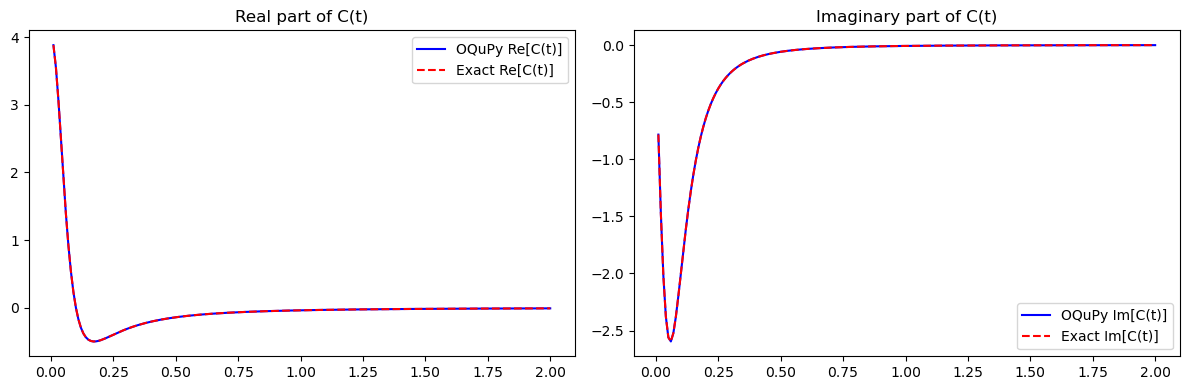

In [4]:
def C_analytical_exact(t, alpha, omega_c):
    return 2.0 * alpha / (1.0/omega_c + 1j*t)**2

# ── Plot ────────────────────────────────────────────────────────────────────
t_vals = np.linspace(0.01, 2.0, 200)

C_oqupy = np.array([correlations.correlation(t) for t in t_vals])
C_exact = C_analytical_exact(t_vals, alpha, omega_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vals, np.real(C_oqupy),  'b-',  label='OQuPy Re[C(t)]')
axes[0].plot(t_vals, np.real(C_exact),  'r--', label='Exact Re[C(t)]')
axes[0].set_title("Real part of C(t)")
axes[0].legend()

axes[1].plot(t_vals, np.imag(C_oqupy),  'b-',  label='OQuPy Im[C(t)]')
axes[1].plot(t_vals, np.imag(C_exact),  'r--', label='Exact Im[C(t)]')
axes[1].set_title("Imaginary part of C(t)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Spectral density

Define the spectral density corresponding to the chosen bath convention and visualize the cutoff behaviour.

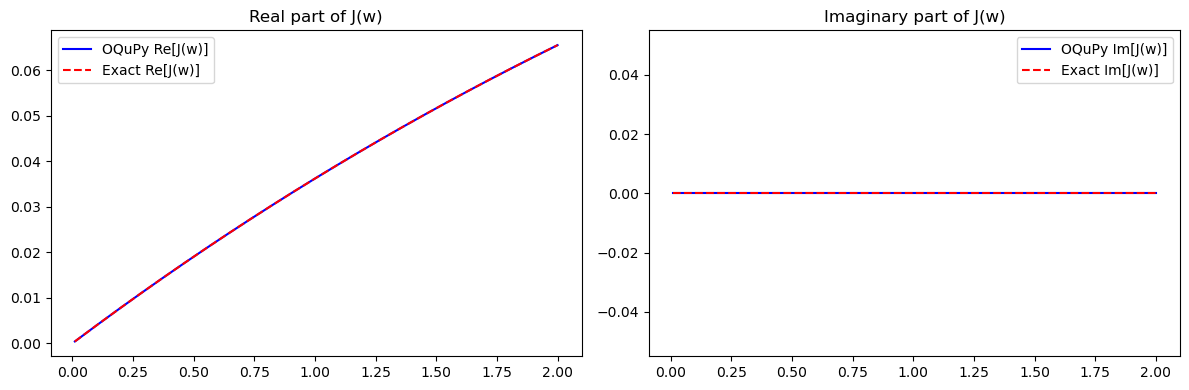

In [5]:
def J_spectralal_exact(w, alpha, omega_c):
    return 2.0 * alpha * w * np.exp(-w / omega_c)

# ── Plot ────────────────────────────────────────────────────────────────────
w_vals = np.linspace(0.01, 2.0, 200)

J_oqupy = np.array([correlations.spectral_density(w) for w in w_vals])
J_exact = J_spectralal_exact(w_vals, alpha, omega_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(w_vals, np.real(J_oqupy),  'b-',  label='OQuPy Re[J(w)]')
axes[0].plot(w_vals, np.real(J_exact),  'r--', label='Exact Re[J(w)]')
axes[0].set_title("Real part of J(w)")
axes[0].legend()

axes[1].plot(w_vals, np.imag(J_oqupy),  'b-',  label='OQuPy Im[J(w)]')
axes[1].plot(w_vals, np.imag(J_exact),  'r--', label='Exact Im[J(w)]')
axes[1].set_title("Imaginary part of J(w)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Final TEMPO simulation

Run the final OQuPy/TEMPO calculation using the chosen convergence parameters.

In [6]:
# =====================================================
# 5. TEMPO parameters
# =====================================================
dt       = 0.26             # time step
epsrel   = 1e-12            # relative SVD truncation error
t_end    = 10.0             # final simulation time
tcut     = t_end            # memory cut-off time

# =====================================================
# 6. Run the simulation
# =====================================================
result = run_oqupy_dynamics(H_sys, A, correlations, rho0,
                            dt=dt, tcut=tcut, epsrel=epsrel, t_end=t_end)

times = result["times"]
states = result["states"]

# Extract ρ_01 coherence for all time steps
coherence_oqupy = np.array([state[0, 1] for state in states])



--> PT-TEMPO computation:
100.0%   38 of   38 [########################################] 00:00:05
Elapsed time: 5.1s
--> Compute dynamics:
100.0%   38 of   38 [########################################] 00:00:02
Elapsed time: 2.5s


## 9. Exact analytical coherence

Define the closed-form pure-dephasing coherence function used as the analytical benchmark.

In [7]:
# =====================================================
# 7. Analytical solution for the pure-dephasing model
# =====================================================
def coherence_function(t, omega_0, omega_c, alpha):
    gamma_R = alpha*np.log(1.0 + (omega_c*t)**2)
    return np.exp(-1j * omega_0 * t - (Delta**2) * gamma_R)



## 10. TEMPO versus exact solution

Compare the numerical TEMPO coherence with the analytical pure-dephasing result.

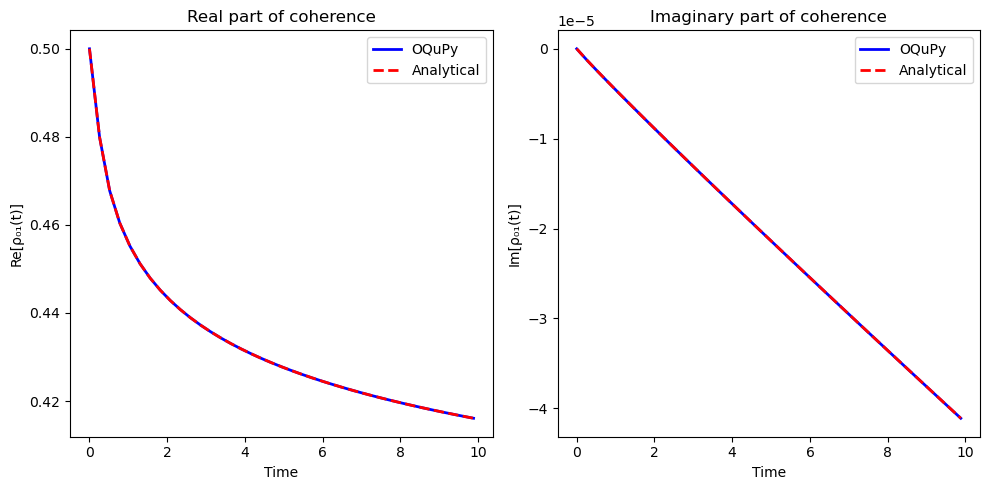

Maximum absolute error between OQuPy and analytical solution: 9.07e-08
Maximum deviation of population from 0.5: 7.49e-12


In [8]:
coherence_analytical = coherence_oqupy[0] * coherence_function(times, omega0, omega_c, alpha)

# =====================================================
# 8. Comparison and plot
# =====================================================
plt.figure(figsize=(10, 5))

# Real part
plt.subplot(1, 2, 1)
plt.plot(times, np.real(coherence_oqupy), 'b-', label='OQuPy', linewidth=2)
plt.plot(times, np.real(coherence_analytical), 'r--', label='Analytical', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Re[ρ₀₁(t)]')
plt.legend()
plt.title('Real part of coherence')

# Imaginary part
plt.subplot(1, 2, 2)
plt.plot(times, np.imag(coherence_oqupy), 'b-', label='OQuPy', linewidth=2)
plt.plot(times, np.imag(coherence_analytical), 'r--', label='Analytical', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Im[ρ₀₁(t)]')
plt.legend()
plt.title('Imaginary part of coherence')

plt.tight_layout()
plt.show()

# =====================================================
# 9. Quantitative error check
# =====================================================
error = np.max(np.abs(coherence_oqupy - coherence_analytical))
print(f"Maximum absolute error between OQuPy and analytical solution: {error:.2e}")

# Also verify that populations remain constant (as expected)
pop0_oqupy = np.array([state[0, 0].real for state in states])
pop1_oqupy = np.array([state[1, 1].real for state in states])
pop_deviation = np.max(np.abs(pop0_oqupy - 0.5))
print(f"Maximum deviation of population from 0.5: {pop_deviation:.2e}")